# Отбор признаков: теория и методы

---

## 1. Постановка задачи

Пусть дана выборка $X^n = \{(x_i, y_i)\}_{i=1}^{n}$, каждый объект описывается $d$ признаками. Требуется найти подмножество признаков $A \subseteq \{1, \ldots, d\}$, минимизирующее критерий качества (ошибку):

$$A^* = \arg\min_{A \subseteq \{1,\ldots,d\}} Q(A, X^n)$$

где $Q(A, X^n)$ — скользящая оценка риска модели, обученной только на признаках из $A$.

Пространство поиска — все подмножества $2^d$ (булев гиперкуб). При $d = 40$ это $\approx 10^{12}$ вариантов — полный перебор невозможен, нужны эвристики.

---

## 2. Полный перебор (эталон)

**Определение.** Вычисляется $Q(A)$ для всех $2^d$ подмножеств признаков.

$$A^* = \arg\min_{A \subseteq \{1,\ldots,d\}} Q(A)$$

**Нижняя огибающая** — функция лучшего достижимого качества при заданном числе признаков $k$:

$$\text{env}(k) = \min_{\substack{A \subseteq \{1,\ldots,d\} \\ |A| = k}} Q(A), \quad k = 0, 1, \ldots, d$$

Нижняя огибающая — **абсолютный эталон**: ни один алгоритм не может показать результат лучше неё при том же числе признаков.

**Сложность:** $O(2^d)$. Применимо только при $d \leq 20{-}25$.

---

## 3. Жадные алгоритмы

### 3.1 Add (Sequential Forward Selection, SFS)

Начинаем с пустого множества. На каждом шаге добавляем признак, дающий наибольшее улучшение:

$$j^* = \arg\min_{j \notin A} Q(A \cup \{j\})$$
$$A \leftarrow A \cup \{j^*\}$$

Останавливаемся, когда добавление любого признака ухудшает $Q$, или $|A| = d$.

**Сложность:** $O(d^2)$ вычислений $Q$.

### 3.2 Del (Sequential Backward Elimination, SBE)

Начинаем с полного набора признаков. На каждом шаге удаляем наименее важный:

$$j^* = \arg\min_{j \in A} Q(A \setminus \{j\})$$
$$A \leftarrow A \setminus \{j^*\}$$

**Сложность:** $O(d^2)$.

### 3.3 Add-Del (Bidirectional / SFFS)

Чередуем фазы добавления и удаления. После каждого добавления пытаемся удалить признак, ставший лишним, и наоборот. Позволяет частично исправить ранние жадные решения:

$$\text{добавить } j^* \;\to\; \text{попробовать удалить любой } j' \in A \text{ с улучшением}$$

Повторяем до стабилизации. **Сложность:** $O(d^2)$, но практически проходит больше итераций.

---

## 4. Поиск в пространстве признаков

Пространство поиска — ориентированный граф: вершины — подмножества, рёбра — добавление одного признака.

### 4.1 Поиск в глубину (DFS)

Рекурсивно расширяет текущее подмножество, добавляя по одному признаку. Запоминает лучшее найденное. Может использовать **отсечение ветвей (branch & bound)**: если текущий $Q(A)$ уже хуже глобального оптимума, ветвь не раскрывается.

$$\text{если } Q(A) \geq Q^* \Rightarrow \text{отсечь поддерево}$$

**Сложность в худшем случае:** $O(2^d)$, но отсечение существенно ускоряет.

### 4.2 Поиск в ширину (BFS)

Уровень за уровнем раскрывает все подмножества размера $k = 0, 1, 2, \ldots$ Гарантирует нахождение оптимума при данном $k$ до перехода к $k+1$. Можно останавливаться при достижении заданного качества.

**Сложность:** $O(2^d)$, но на практике останавливается раньше. Требует больше памяти, чем DFS.

---

## 5. Генетический алгоритм

Метаэвристика, вдохновлённая биологической эволюцией. Каждое подмножество кодируется **битовой строкой** длины $d$: $g \in \{0,1\}^d$, где $g_j = 1$ означает включение признака $j$.

**Алгоритм:**

1. **Инициализация:** случайная популяция из $N$ особей.
2. **Фитнес:** $f(g) = -Q(A_g)$ (минус ошибка — максимизируем).
3. **Селекция:** выбираем родителей с вероятностью $\propto f(g)$ (рулетка или турнир).
4. **Скрещивание (crossover):** одноточечное или двухточечное — обмен частями битовых строк.
5. **Мутация:** с вероятностью $p_m$ инвертируем бит $g_j \leftarrow 1 - g_j$.
6. **Замена:** новая популяция (elitism — лучшие особи переходят).
7. **Повтор** шагов 2–6 до сходимости или исчерпания бюджета.

**Параметры:** размер популяции $N$, вероятность мутации $p_m$, число поколений $T$.

**Сложность:** $O(T \cdot N)$ вычислений $Q$. Находит хорошие решения при $d \gg 25$.

---

## 6. СПА — Стохастический Поиск с Адаптацией

Поддерживает **вектор вероятностей** $p = (p_1, \ldots, p_d) \in [0,1]^d$, где $p_j$ — вероятность включения признака $j$ в подмножество.

**Алгоритм:**

1. **Инициализация:** $p_j = 0.5 \;\forall j$, $Q^* = +\infty$, $A^* = \varnothing$.
2. На каждой итерации $r = 1, \ldots, T$:
   - Сэмплируем маску: $g_j \sim \mathrm{Bernoulli}(p_j)$.
   - Вычисляем $Q(A_g)$.
   - Если $Q(A_g) < Q^*$: обновляем $Q^*$, $A^*$, адаптируем вероятности **к текущей маске**:
     $$p_j \leftarrow p_j + \alpha\,(g_j - p_j)$$
   - Иначе (опционально) — слабый сдвиг к текущему оптимуму:
     $$p_j \leftarrow p_j + \beta\,(g_j^* - p_j), \quad \beta \ll \alpha$$
3. Периодически добавляем **шум** $\varepsilon$, чтобы не застрять: $p_j \leftarrow \text{clip}(p_j + \varepsilon_j,\; \delta,\; 1-\delta)$.

СПА — частный случай алгоритма PBIL (Population-Based Incremental Learning). Хорошо масштабируется, не требует градиентов.

**Параметры:** $\alpha$ (скорость адаптации), $\beta$ (сила притяжения к оптимуму), $\delta$ (минимальная вероятность), $T$ (число итераций).

---

## 7. Сравнение методов

**Нижняя огибающая** (из полного перебора) — эталон, относительно которого оцениваем все методы.

In [102]:
from abc import ABC, abstractmethod
from collections import deque
from itertools import combinations
from typing import Callable

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

In [12]:
# Тип: оценочная функция Q(indices, X, y) -> float
ScoreFn = Callable[[list[int], np.ndarray, np.ndarray], float]

In [13]:
class SelectionResult:
    def __init__(
            self,
            method_name: str,
            best_features: list[int],
            best_score: float,
            history: list[dict] | None = None,
            n_evaluated: int = 0,
            extra: dict | None = None,
    ):
        self.method_name = method_name
        self.best_features = sorted(int(f) for f in best_features)
        self.best_score = best_score
        self.history = history or []
        self.n_evaluated = n_evaluated
        self.extra = extra or {}

    def summary(self) -> dict:
        return {
            "Method": self.method_name,
            "Features": self.best_features,
            "n_features": len(self.best_features),
            "Score": round(self.best_score, 6),
            "Evaluated": self.n_evaluated,
        }

In [14]:
class BaseSelector(ABC):
    name: str = ""

    @abstractmethod
    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        pass

    def __repr__(self):
        return f"{self.__class__.__name__}()"

In [44]:
class ExhaustiveSelector(BaseSelector):
    name: str = "ExhaustiveSelector"

    def __init__(
            self,
            max_features: int | None = None,
            max_subsets: int | None = 50_000,
            verbose: bool = False,
    ):
        self.max_features = max_features
        self.max_subsets = max_subsets
        self.verbose = verbose

        self.all_results: list[dict] = []

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        d = n_features
        max_k = self.max_features or d
        all_indices = list(range(d))

        subsets = []
        for k in range(0, max_k + 1):
            subsets.extend(combinations(all_indices, k))

        if self.max_subsets is not None:
            subsets = subsets[:self.max_subsets]

        best_score = np.inf
        best_features = []
        history = []
        all_results = []

        for step, subset in enumerate(subsets):
            features = list(subset)
            score = score_fn(features, X, y)
            record = {
                "features": features,
                "size": len(features),
                "score": round(score, 3),
                "step": step,
            }
            all_results.append(record)
            history.append(record)

            if score < best_score:
                best_score = score
                best_features = features

            if self.verbose and step % 100 == 0:
                print(f"[{self.name}] step={step}/{len(subsets)}, best={best_score:.3f}")

        self.all_results = all_results
        return SelectionResult(
            method_name=self.name,
            best_features=best_features,
            best_score=best_score,
            history=history,
            n_evaluated=len(subsets),
        )

    def lower_envelope(self) -> dict[int, float]:
        if not self.all_results:
            raise RuntimeError("`select(...)` method must be called before `lower_envelope()`")

        envelope = {}
        for record in self.all_results:
            k = record["size"]
            q = record["score"]
            if k not in envelope or q < envelope[k]:
                envelope[k] = q

        return dict(sorted(envelope.items()))

    def lover_envelope_features(self) -> dict[int, list[int]]:
        if not self.all_results:
            raise RuntimeError("`select(...)` method must be called before `lover_envelope_features()`")

        best = {}
        for record in self.all_results:
            k = record["size"]
            if k not in best or record["score"] < best[k]["score"]:
                best[k] = record

        return {k: v["features"] for k, v in sorted(best.items())}

In [16]:
class AddSelector(BaseSelector):
    name: str = "AddSelector"

    def __init__(self, max_features: int | None = None):
        self.max_features = max_features

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        d = n_features
        selected = []
        remaining = list(range(d))
        max_k = self.max_features or d

        best_score = score_fn(selected, X, y)
        history = [{"features": [], "score": best_score, "step": 0, "action": "init"}]
        n_eval = 1

        for step in range(max_k):
            if not remaining:
                break

            candidate_score = np.inf
            candidate_feat = None

            for feat in remaining:
                trial = selected + [feat]
                score = score_fn(trial, X, y)
                n_eval += 1
                if score < candidate_score:
                    candidate_score = score
                    candidate_feat = feat

            if candidate_score < best_score:
                best_score = candidate_score
                selected.append(candidate_feat)
                remaining.remove(candidate_feat)
                history.append({
                    "features": list(selected),
                    "score": best_score,
                    "step": step + 1,
                    "action": f"add {candidate_feat}",
                })
            else:
                break

        return SelectionResult(
            method_name=self.name,
            best_features=selected,
            best_score=best_score,
            history=history,
            n_evaluated=n_eval,
        )


class DelSelector(BaseSelector):
    name = "DelSelector"

    def __init__(self, min_features: int = 1):
        self.min_features = min_features

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        d = n_features
        selected = list(range(d))

        best_score = score_fn(selected, X, y)
        history = [{"features": list(selected), "score": best_score, "step": 0, "action": "init"}]
        n_eval = 1

        step = 0
        while len(selected) > self.min_features:
            candidate_score = np.inf
            candidate_feat = None

            for feat in selected:
                trial = [f for f in selected if f != feat]
                score = score_fn(trial, X, y)
                n_eval += 1
                if score < candidate_score:
                    candidate_score = score
                    candidate_feat = feat

            if candidate_score < best_score:
                best_score = candidate_score
                selected.remove(candidate_feat)
                step += 1
                history.append({
                    "features": list(selected),
                    "score": best_score,
                    "step": step,
                    "action": f"del {candidate_feat}",
                })
            else:
                break

        return SelectionResult(
            method_name=self.name,
            best_features=selected,
            best_score=best_score,
            history=history,
            n_evaluated=n_eval,
        )


class AddDelSelector(BaseSelector):
    name = "AddDelSelector"

    def __init__(self, max_features: int | None = None, max_iter: int = 100):
        self.max_features = max_features
        self.max_iter = max_iter

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        d = n_features
        selected = []
        remaining = list(range(d))
        max_k = self.max_features or d

        best_score = score_fn(selected, X, y)
        history = [{"features": [], "score": best_score, "step": 0, "action": "init"}]
        n_eval = 1
        step = 0

        for iteration in range(self.max_iter):
            improved = False

            if remaining and len(selected) < max_k:
                candidate_score = np.inf
                candidate_feat = None

                for feat in remaining:
                    score = score_fn(selected + [feat], X, y)
                    n_eval += 1
                    if score < candidate_score:
                        candidate_score = score
                        candidate_feat = feat

                if candidate_score < best_score:
                    best_score = candidate_score
                    selected.append(candidate_feat)
                    remaining.remove(candidate_feat)
                    step += 1
                    history.append({
                        "features": list(selected),
                        "score": best_score,
                        "step": step,
                        "action": f"add {candidate_feat}",
                    })
                    improved = True

            if len(selected) > 1:
                del_improved = True
                while del_improved and len(selected) > 1:
                    del_improved = False
                    candidate_score = np.inf
                    candidate_feat = None

                    for feat in selected:
                        trial = [f for f in selected if f != feat]
                        score = score_fn(trial, X, y)
                        n_eval += 1
                        if score < candidate_score:
                            candidate_score = score
                            candidate_feat = feat

                    if candidate_score < best_score:
                        best_score = candidate_score
                        selected.remove(candidate_feat)
                        remaining.append(candidate_feat)
                        remaining.sort()
                        step += 1
                        history.append({
                            "features": list(selected),
                            "score": best_score,
                            "step": step,
                            "action": f"del {candidate_feat}",
                        })
                        improved = True
                        del_improved = True

            if not improved:
                break

        return SelectionResult(
            method_name=self.name,
            best_features=selected,
            best_score=best_score,
            history=history,
            n_evaluated=n_eval,
        )

In [17]:
class DFSSelector(BaseSelector):
    name: str = "DFSSelector"

    def __init__(
            self,
            max_features: int | None = None,
            max_evaluations: int | None = 5_000,
            use_pruning: bool = True,
    ):
        self.max_features = max_features
        self.max_evaluations = max_evaluations
        self.use_pruning = use_pruning

        self._best_score = np.inf
        self._best_features = []
        self._history = []
        self._n_eval = 0
        self._budget_hit = False

    def _clear_state(self):
        self._best_score = np.inf
        self._best_features = []
        self._history = []
        self._n_eval = 0
        self._budget_hit = False

    def _dfs(
            self,
            score_fn: ScoreFn,
            X: np.ndarray,
            y: np.ndarray,
            current: list,
            start_from: int,
            max_k: int,
            d: int,
            step_ref: list
    ):
        if self._budget_hit:
            return

        score = score_fn(current, X, y)
        self._n_eval += 1

        step_ref[0] += 1
        self._history.append({
            "features": list(current),
            "score": score,
            "step": step_ref[0],
            "action": f"dfs visit {current}",
        })

        if score < self._best_score:
            self._best_score = score
            self._best_features = list(current)

        if self.max_evaluations is not None and self._n_eval >= self.max_evaluations:
            self._budget_hit = True
            return

        if self.use_pruning and score > self._best_score and len(current) > 0:
            return

        if len(current) >= max_k:
            return

        for feat in range(start_from, d):
            if self._budget_hit:
                break
            self._dfs(
                score_fn, X, y,
                current=current + [feat],
                start_from=feat + 1,
                max_k=max_k,
                d=d,
                step_ref=step_ref,
            )

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        self._clear_state()
        d = n_features
        max_k = self.max_features or d

        empty_score = score_fn([], X, y)
        self._n_eval += 1
        self._best_score = empty_score
        self._best_features = []
        self._history.append({"features": [], "score": empty_score, "step": 0, "action": "init"})

        for start in range(d):
            if self._budget_hit:
                break

            self._dfs(
                score_fn,
                X,
                y,
                current=[start],
                start_from=start + 1,
                max_k=max_k, d=d,
                step_ref=[len(self._history)]
            )

        return SelectionResult(
            method_name=self.name,
            best_features=self._best_features,
            best_score=self._best_score,
            history=self._history,
            n_evaluated=self._n_eval,
        )


class BFSSelector(BaseSelector):
    name: str = "BFSSelector"

    def __init__(
            self,
            max_features: int | None = None,
            max_evaluations: int | None = 5_000,
            beam_width: int | None = None,
    ):
        self.max_features = max_features
        self.max_evaluations = max_evaluations
        self.beam_width = beam_width

    def _clear_state(self):
        self._best_score = np.inf
        self._best_features = []
        self._history = []
        self._n_eval = 0
        self._budget_hit = False

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:

        d = n_features
        max_k = self.max_features or d
        n_eval = 0

        empty_score = score_fn([], X, y)
        n_eval += 1

        best_score = empty_score
        best_features = []
        history = [{"features": [], "score": empty_score, "step": 0, "action": "init"}]

        queue: deque = deque()
        for feat in range(d):
            queue.append((frozenset([feat]), feat))

        visited: set[frozenset] = set()
        visited.add(frozenset())

        step = 0

        while queue:
            if self.max_evaluations is not None and n_eval >= self.max_evaluations:
                break

            if self.beam_width is not None:
                level_items = list(queue)
                cur_level_size = len(next(iter(queue))[0]) if queue else 0
                same_level = [(fs, li) for fs, li in level_items if len(fs) == cur_level_size]
                rest = [(fs, li) for fs, li in level_items if len(fs) != cur_level_size]

                scored = []
                for fs, li in same_level:
                    if fs in visited:
                        continue
                    visited.add(fs)
                    feats = sorted(fs)
                    score = score_fn(feats, X, y)
                    n_eval += 1
                    step += 1
                    history.append({"features": feats, "score": score, "step": step, "action": "bfs"})
                    if score < best_score:
                        best_score = score
                        best_features = feats
                    scored.append((fs, li, score))

                scored.sort(key=lambda x: x[2])
                queue = deque([(fs, li) for fs, li, _ in scored[:self.beam_width]] + rest)
                for fs, li, _ in scored[:self.beam_width]:
                    if len(fs) < max_k:
                        for feat in range(li + 1, d):
                            new_fs = fs | frozenset([feat])
                            if new_fs not in visited:
                                queue.append((new_fs, feat))
                continue

            fs, last_idx = queue.popleft()

            if fs in visited:
                continue
            visited.add(fs)

            feats = sorted(fs)
            if len(feats) > max_k:
                continue

            score = score_fn(feats, X, y)
            n_eval += 1
            step += 1
            history.append({"features": feats, "score": score, "step": step, "action": "bfs"})

            if score < best_score:
                best_score = score
                best_features = feats

            if len(feats) < max_k:
                for feat in range(last_idx + 1, d):
                    new_fs = fs | frozenset([feat])
                    if new_fs not in visited:
                        queue.append((new_fs, feat))

        return SelectionResult(
            method_name=self.name,
            best_features=best_features,
            best_score=best_score,
            history=history,
            n_evaluated=n_eval,
        )

In [18]:
class GeneticSelector(BaseSelector):
    name = "GeneticSelector"

    def __init__(
            self,
            population_size: int = 30,
            n_generations: int = 50,
            crossover_prob: float = 0.8,
            mutation_prob: float = 0.05,
            elitism_k: int = 2,
            selection: str = "tournament",
            tournament_k: int = 3,
            min_features: int = 1,
            seed: int | None = 42,
    ):
        self.population_size = population_size
        self.n_generations = n_generations
        self.crossover_prob = crossover_prob
        self.mutation_prob = mutation_prob
        self.elitism_k = elitism_k
        self.selection = selection
        self.tournament_k = tournament_k
        self.min_features = min_features
        self.seed = seed

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        d = n_features
        rng = np.random.RandomState(self.seed)

        population = self._init_population(d, rng)
        fitness = np.array([self._evaluate(ind, score_fn, X, y) for ind in population])

        best_idx = np.argmin(fitness)
        best_score = fitness[best_idx]
        best_ind = population[best_idx].copy()
        history = []
        n_eval = len(population)

        history.append({
            "features": self._to_features(best_ind),
            "score": best_score,
            "step": 0,
            "action": "init",
            "generation": 0,
        })

        for gen in range(1, self.n_generations + 1):
            new_population = []

            # Элитизм: лучшие особи переходят напрямую
            elite_idx = np.argsort(fitness)[: self.elitism_k]
            for idx in elite_idx:
                new_population.append(population[idx].copy())

            # Заполняем оставшуюся часть популяции
            while len(new_population) < self.population_size:
                parent1 = self._select_parent(population, fitness, rng)
                parent2 = self._select_parent(population, fitness, rng)

                if rng.random() < self.crossover_prob:
                    child1, child2 = self._crossover(parent1, parent2, d, rng)
                else:
                    child1, child2 = parent1.copy(), parent2.copy()

                child1 = self._mutate(child1, d, rng)
                child2 = self._mutate(child2, d, rng)

                child1 = self._enforce_min(child1, d, rng)
                child2 = self._enforce_min(child2, d, rng)

                new_population.append(child1)
                if len(new_population) < self.population_size:
                    new_population.append(child2)

            population = new_population
            fitness = np.array([self._evaluate(ind, score_fn, X, y) for ind in population])
            n_eval += len(population)

            gen_best_idx = np.argmin(fitness)
            gen_best = fitness[gen_best_idx]

            if gen_best < best_score:
                best_score = gen_best
                best_ind = population[gen_best_idx].copy()

            history.append({
                "features": self._to_features(best_ind),
                "score": best_score,
                "step": gen,
                "action": f"gen {gen}",
                "generation": gen,
                "gen_mean": float(np.mean(fitness)),
                "gen_std": float(np.std(fitness)),
            })

        return SelectionResult(
            method_name=self.name,
            best_features=self._to_features(best_ind),
            best_score=best_score,
            history=history,
            n_evaluated=n_eval,
        )

    def _init_population(self, d: int, rng) -> list[np.ndarray]:
        pop = []
        for _ in range(self.population_size):
            ind = rng.randint(0, 2, size=d)
            ind = self._enforce_min(ind, d, rng)
            pop.append(ind)
        return pop

    def _evaluate(self, ind: np.ndarray, score_fn, X, y) -> float:
        features = self._to_features(ind)
        return score_fn(features, X, y)

    @staticmethod
    def _to_features(ind: np.ndarray) -> list[int]:
        return list(np.where(ind)[0])

    def _enforce_min(self, ind: np.ndarray, d: int, rng) -> np.ndarray:
        """Если включено < min_features — случайно включаем недостающие."""
        ind = ind.copy()
        active = int(ind.sum())
        if active < self.min_features:
            zeros = np.where(ind == 0)[0]
            need = self.min_features - active
            chosen = rng.choice(zeros, size=min(need, len(zeros)), replace=False)
            ind[chosen] = 1
        return ind

    def _select_parent(self, population, fitness, rng) -> np.ndarray:
        if self.selection == "tournament":
            idx = rng.choice(len(population), size=self.tournament_k, replace=False)
            best = idx[np.argmin(fitness[idx])]
            return population[best].copy()

        elif self.selection == "roulette":
            inv = 1.0 / (fitness + 1e-10)
            probs = inv / inv.sum()
            chosen = rng.choice(len(population), p=probs)
            return population[chosen].copy()

        raise ValueError(f"Unknown selection strategy: {self.selection}")

    @staticmethod
    def _crossover(p1, p2, d, rng):
        pts = sorted(rng.choice(d - 1, size=2, replace=False) + 1)
        c1 = np.concatenate([p1[:pts[0]], p2[pts[0]:pts[1]], p1[pts[1]:]])
        c2 = np.concatenate([p2[:pts[0]], p1[pts[0]:pts[1]], p2[pts[1]:]])
        return c1, c2

    def _mutate(self, ind: np.ndarray, d: int, rng) -> np.ndarray:
        ind = ind.copy()
        for j in range(d):
            if rng.random() < self.mutation_prob:
                ind[j] = 1 - ind[j]
        return ind

In [19]:
class SPASelector(BaseSelector):
    name: str = "SPASelector"

    def __init__(
            self,
            n_iterations: int = 200,
            alpha: float = 0.3,
            beta: float = 0.05,
            noise_std: float = 0.02,
            p_clip: float = 0.05,
            min_features: int = 1,
            seed: int | None = 42,
    ):
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.noise_std = noise_std
        self.p_clip = p_clip
        self.min_features = min_features
        self.seed = seed

        self._p_history = None

    def select(
            self,
            score_fn: ScoreFn,
            n_features: int,
            X: np.ndarray,
            y: np.ndarray,
    ) -> SelectionResult:
        d = n_features
        rng = np.random.RandomState(self.seed)

        # Вектор вероятностей — стартуем с равномерного 0.5
        p = np.full(d, 0.5)

        best_score = np.inf
        best_features = []
        best_mask = np.zeros(d)
        history = []
        n_eval = 0

        # Лог вероятностей для визуализации
        p_history = [p.copy()]

        for it in range(self.n_iterations):
            # ── Шаг 1: сэмплируем маску ──────────────────────────────
            mask = (rng.random(d) < p).astype(int)

            # Гарантируем минимальное число признаков
            if mask.sum() < self.min_features:
                zeros = np.where(mask == 0)[0]
                need = self.min_features - int(mask.sum())
                chosen = rng.choice(zeros, size=min(need, len(zeros)), replace=False)
                mask[chosen] = 1

            features = list(np.where(mask)[0])

            # ── Шаг 2: оцениваем ─────────────────────────────────────
            score = score_fn(features, X, y)
            n_eval += 1

            # ── Шаг 3: обновляем оптимум и адаптируем p ──────────────
            if score < best_score:
                best_score = score
                best_features = features
                best_mask = mask.copy()
                # Сильная адаптация к новому лучшему
                p = p + self.alpha * (mask - p)

            # ── Шаг 4: слабое притяжение к текущему оптимуму ─────────
            p = p + self.beta * (best_mask - p)

            # ── Шаг 5: шум — сохраняем разнообразие ──────────────────
            noise = rng.normal(0, self.noise_std, size=d)
            p = p + noise
            p = np.clip(p, self.p_clip, 1.0 - self.p_clip)

            p_history.append(p.copy())
            history.append({
                "features": features,
                "score": score,
                "step": it,
                "action": f"spa iter {it}",
                "p_mean": float(p.mean()),
                "p_entropy": float(-np.sum(p * np.log(p + 1e-10) + (1 - p) * np.log(1 - p + 1e-10))),
                "best_score": best_score,
            })

        self._p_history = np.array(p_history)

        return SelectionResult(
            method_name=self.name,
            best_features=best_features,
            best_score=best_score,
            history=history,
            n_evaluated=n_eval,
            extra={"p_final": p, "p_history": self._p_history},
        )

In [48]:
class FSComparator:

    def __init__(self, exhaustive: ExhaustiveSelector | None = None):
        self.exhaustive = exhaustive
        self.results: list[SelectionResult] = []
        self._envelope: dict | None = None

        if exhaustive is not None and exhaustive.all_results:
            self._envelope = exhaustive.lower_envelope()

    def add(self, result: SelectionResult):
        self.results.append(result)
        return self

    def __iadd__(self, result: SelectionResult):
        return self.add(result)

    def table(self) -> pd.DataFrame:
        if not self.results:
            raise ValueError("No results available.")

        rows = []
        for r in self.results:
            row = r.summary()
            if self._envelope:
                k = len(r.best_features)
                env = self._envelope.get(k)
                row["Envelope (k)"] = round(env, 6) if env else "—"
                row["Δ_envelope"] = round(r.best_score - env, 6) if env else "—"
            rows.append(row)

        return pd.DataFrame(rows).set_index("Method")

    def plot(
            self,
            figsize: tuple = (18, 14),
            title: str = "Сравнение алгоритмов отбора признаков",
    ):
        n_methods = len(self.results)
        COLORS = plt.cm.tab10(np.linspace(0, 0.9, n_methods))

        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

        # ── 1. Нижняя огибающая + точки методов ─────────────────────
        ax1 = fig.add_subplot(gs[0, :])
        self._plot_envelope(ax1, COLORS)

        # ── 2. Convergence curves ────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, 0])
        self._plot_convergence(ax2, COLORS)

        # ── 3. Score vs n_features barplot ───────────────────────────
        ax3 = fig.add_subplot(gs[1, 1])
        self._plot_score_vs_size(ax3, COLORS)

        # ── 4. Число оцениваний Q (efficiency) ───────────────────────
        ax4 = fig.add_subplot(gs[2, 0])
        self._plot_efficiency(ax4, COLORS)

        # ── 5. Тепловая карта выбранных признаков ────────────────────
        ax5 = fig.add_subplot(gs[2, 1])
        self._plot_feature_heatmap(ax5)

        plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
        plt.tight_layout()
        plt.show()

    def _plot_envelope(self, ax, COLORS):
        """Нижняя огибающая + результаты всех методов."""
        # Рисуем облако всех точек полного перебора
        scores = []
        if self.exhaustive and self.exhaustive.all_results:
            sizes = [r["size"] for r in self.exhaustive.all_results]
            scores = [r["score"] for r in self.exhaustive.all_results]
            ax.scatter(sizes, scores, alpha=0.08, s=8, color="steelblue",
                       label="Все подмножества", zorder=1)

        # Нижняя огибающая
        if self._envelope:
            ks = sorted(self._envelope.keys())
            env = [self._envelope[k] for k in ks]
            ax.plot(ks, env, "r-o", linewidth=2.5, markersize=5,
                    label="Нижняя огибающая", zorder=4, color="crimson")
            ax.fill_between(ks, env,
                            [max(scores) if self.exhaustive and self.exhaustive.all_results else max(env)] * len(ks),
                            alpha=0.06, color="crimson")

        # Точки результатов методов
        for i, (r, color) in enumerate(zip(self.results, COLORS)):
            k = len(r.best_features)
            ax.scatter(k, r.best_score,
                       color=color, s=140, zorder=5, edgecolors="black",
                       linewidth=0.8, label=r.method_name)
            ax.annotate(r.method_name, (k, r.best_score),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7.5, color=color)

        ax.set_title("Нижняя огибающая полного перебора + результаты методов",
                     fontweight="bold")
        ax.set_xlabel("Число признаков |A|")
        ax.set_ylabel("Ошибка Q(A)")
        ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    def _plot_convergence(self, ax, COLORS):
        """Кривые сходимости: лучший score по шагам."""
        for r, color in zip(self.results, COLORS):
            if not r.history:
                continue
            steps = [h["step"] for h in r.history]
            scores = [h["score"] for h in r.history]
            # Накопленный минимум
            best_so_far = np.minimum.accumulate(scores)
            ax.plot(steps, best_so_far, color=color, linewidth=1.8,
                    label=r.method_name, alpha=0.9)

        ax.set_title("Сходимость: лучший score по шагам", fontweight="bold")
        ax.set_xlabel("Шаг / итерация")
        ax.set_ylabel("Лучшая ошибка Q")
        ax.legend(fontsize=8)

    def _plot_score_vs_size(self, ax, COLORS):
        """Итоговый score vs число признаков для каждого метода."""
        names = [r.method_name for r in self.results]
        scores = [r.best_score for r in self.results]
        sizes = [len(r.best_features) for r in self.results]

        # Нижняя огибающая как фоновая линия
        if self._envelope:
            ks = sorted(self._envelope.keys())
            env = [self._envelope[k] for k in ks]
            ax.plot(ks, env, "r--", linewidth=1.5, alpha=0.6,
                    label="Огибающая", zorder=1)

        sc = ax.scatter(sizes, scores, c=list(range(len(self.results))),
                        cmap="tab10", s=180, edgecolors="black",
                        linewidth=0.8, zorder=5)
        for i, (r, s, q) in enumerate(zip(self.results, sizes, scores)):
            ax.annotate(r.method_name, (s, q),
                        textcoords="offset points", xytext=(5, 3), fontsize=7.5)

        ax.set_title("Итоговый score vs число признаков", fontweight="bold")
        ax.set_xlabel("Число признаков |A|")
        ax.set_ylabel("Ошибка Q")
        ax.legend(fontsize=8)

    def _plot_efficiency(self, ax, COLORS):
        """Число вычислений Q на каждый метод."""
        names = [r.method_name for r in self.results]
        n_eval = [r.n_evaluated for r in self.results]

        bars = ax.barh(names, n_eval, color=COLORS, edgecolor="black",
                       linewidth=0.7, alpha=0.85)
        for bar, val in zip(bars, n_eval):
            ax.text(val + max(n_eval) * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:,}", va="center", fontsize=9)

        ax.set_title("Вычислительная стоимость (число оценок Q)", fontweight="bold")
        ax.set_xlabel("Число вычислений Q(A)")
        ax.xaxis.get_major_formatter().set_scientific(False)

    def _plot_feature_heatmap(self, ax):
        """Тепловая карта: какие признаки выбраны каждым методом."""
        if not self.results:
            return

        d = max(max(r.best_features, default=0) for r in self.results) + 1
        matrix = np.zeros((len(self.results), d))
        for i, r in enumerate(self.results):
            for f in r.best_features:
                matrix[i, f] = 1

        im = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1,
                       interpolation="nearest")
        ax.set_yticks(range(len(self.results)))
        ax.set_yticklabels([r.method_name for r in self.results], fontsize=8)
        ax.set_xlabel("Индекс признака")
        ax.set_title("Какие признаки выбраны каждым методом", fontweight="bold")

        # Подписи столбцов
        ax.set_xticks(range(d))
        ax.set_xticklabels([f"f{j}" for j in range(d)], fontsize=7, rotation=45)

        plt.colorbar(im, ax=ax, fraction=0.04, label="Включён")

In [133]:
SEED = 42
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#A689E1"]
np.random.seed(SEED)

In [104]:
data = load_wine()

In [107]:
data = load_wine(as_frame=True)
df = data.frame
X_raw = data.data.values
y = data.target.values

In [109]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [110]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [111]:
FEATURE_NAMES = list(data.feature_names)
FEATURE_NAMES

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [112]:
d = X.shape[1]
n = X.shape[0]

In [113]:
print(f"Датасет: {n} × {d}")
print(f"Признаки: {FEATURE_NAMES}")
print(f"y: min={y.min():.1f}  max={y.max():.1f}  mean={y.mean():.1f}")
print(f"Пространство поиска: 2^{d} = {2 ** d} подмножеств")

Датасет: 178 × 13
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
y: min=0.0  max=2.0  mean=0.9
Пространство поиска: 2^13 = 8192 подмножеств


In [115]:
def score_fn(features: list[int], X: np.ndarray, y: np.ndarray) -> float:
    """5-fold для подмножества признаков features."""
    if len(features) == 0:
        return 1.0  # предсказываем средним → нормированная ошибка = 1

    X_sub = X[:, features]
    q = 5
    fold_size = n // q
    scores = []

    for k in range(q):
        test = list(range(k * fold_size, (k + 1) * fold_size))
        train = [i for i in range(n) if i not in test]
        m = RandomForestClassifier(n_estimators=30, random_state=42)
        m.fit(X_sub[train], y[train])
        pred = m.predict(X_sub[test])
        scores.append(1 - f1_score(y[test], pred, average="macro"))

    return float(np.mean(scores))

In [117]:
q_full = score_fn(list(range(d)), X, y)
q_none = score_fn([], X, y)
print(f"Q (все признаки):  {q_full:.4f}")
print(f"Q (нет признаков): {q_none:.4f}")

Q (все признаки):  0.4095  ≈ 1 - F1_score = 0.4095
Q (нет признаков): 1.0000


In [118]:
exh = ExhaustiveSelector(max_subsets=None, verbose=True)
r_exh = exh.select(score_fn, d, X, y)
print(f"Exhaustive:  {r_exh}\n")

[ExhaustiveSelector] step=0/8192, best=1.000
[ExhaustiveSelector] step=100/8192, best=0.473
[ExhaustiveSelector] step=200/8192, best=0.377
[ExhaustiveSelector] step=300/8192, best=0.377
[ExhaustiveSelector] step=400/8192, best=0.352
[ExhaustiveSelector] step=500/8192, best=0.330
[ExhaustiveSelector] step=600/8192, best=0.330
[ExhaustiveSelector] step=700/8192, best=0.330
[ExhaustiveSelector] step=800/8192, best=0.330
[ExhaustiveSelector] step=900/8192, best=0.254
[ExhaustiveSelector] step=1000/8192, best=0.254
[ExhaustiveSelector] step=1100/8192, best=0.254
[ExhaustiveSelector] step=1200/8192, best=0.254
[ExhaustiveSelector] step=1300/8192, best=0.254
[ExhaustiveSelector] step=1400/8192, best=0.254
[ExhaustiveSelector] step=1500/8192, best=0.254
[ExhaustiveSelector] step=1600/8192, best=0.251
[ExhaustiveSelector] step=1700/8192, best=0.251
[ExhaustiveSelector] step=1800/8192, best=0.251
[ExhaustiveSelector] step=1900/8192, best=0.251
[ExhaustiveSelector] step=2000/8192, best=0.251
[Exh

In [119]:
r_add = AddSelector().select(score_fn, d, X, y)

In [120]:
r_del = DelSelector().select(score_fn, d, X, y)

In [121]:
r_addel = AddDelSelector().select(score_fn, d, X, y)

In [122]:
r_dfs = DFSSelector(max_evaluations=800).select(score_fn, d, X, y)

In [123]:
r_bfs = BFSSelector(max_evaluations=800).select(score_fn, d, X, y)

In [124]:
r_gen = GeneticSelector(
    population_size=25, n_generations=40,
    mutation_prob=0.08, seed=SEED
).select(score_fn, d, X, y)

In [125]:
r_spa = SPASelector(
    n_iterations=300, alpha=0.35, beta=0.04,
    noise_std=0.015, seed=SEED
).select(score_fn, d, X, y)

In [126]:
RESULTS = [r_exh, r_add, r_del, r_addel, r_dfs, r_bfs, r_gen, r_spa]
METHOD_NAMES = [r.method_name for r in RESULTS]

In [127]:
envelope = exh.lower_envelope()

In [128]:
cmp = FSComparator(exhaustive=exh)
for r in RESULTS:
    cmp.add(r)

table = cmp.table()
table

,Features,n_features,Score,Evaluated,Envelope (k),Δ_envelope
Method,,,,,,
ExhaustiveSelector,"[2, 3, 4, 5, 6, 9, 10]",7,0.195994,8192,0.196,-0.000006
AddSelector,"[0, 2, 4, 6, 9, 11, 12]",7,0.352170,77,0.196,0.156170
DelSelector,"[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12]",12,0.310156,26,0.310,0.000156
AddDelSelector,"[4, 6, 9]",3,0.248782,89,0.352,-0.103218
DFSSelector,"[0, 1, 4, 5, 6, 12]",6,0.345700,61,0.246,0.099700
BFSSelector,"[0, 3, 6, 9]",4,0.329754,800,0.254,0.075754
GeneticSelector,"[0, 2, 4, 6, 8, 9, 10, 12]",8,0.204390,1025,0.204,0.000390
SPASelector,"[0, 3, 4, 6, 8, 9, 10, 12]",8,0.212685,300,0.204,0.008685


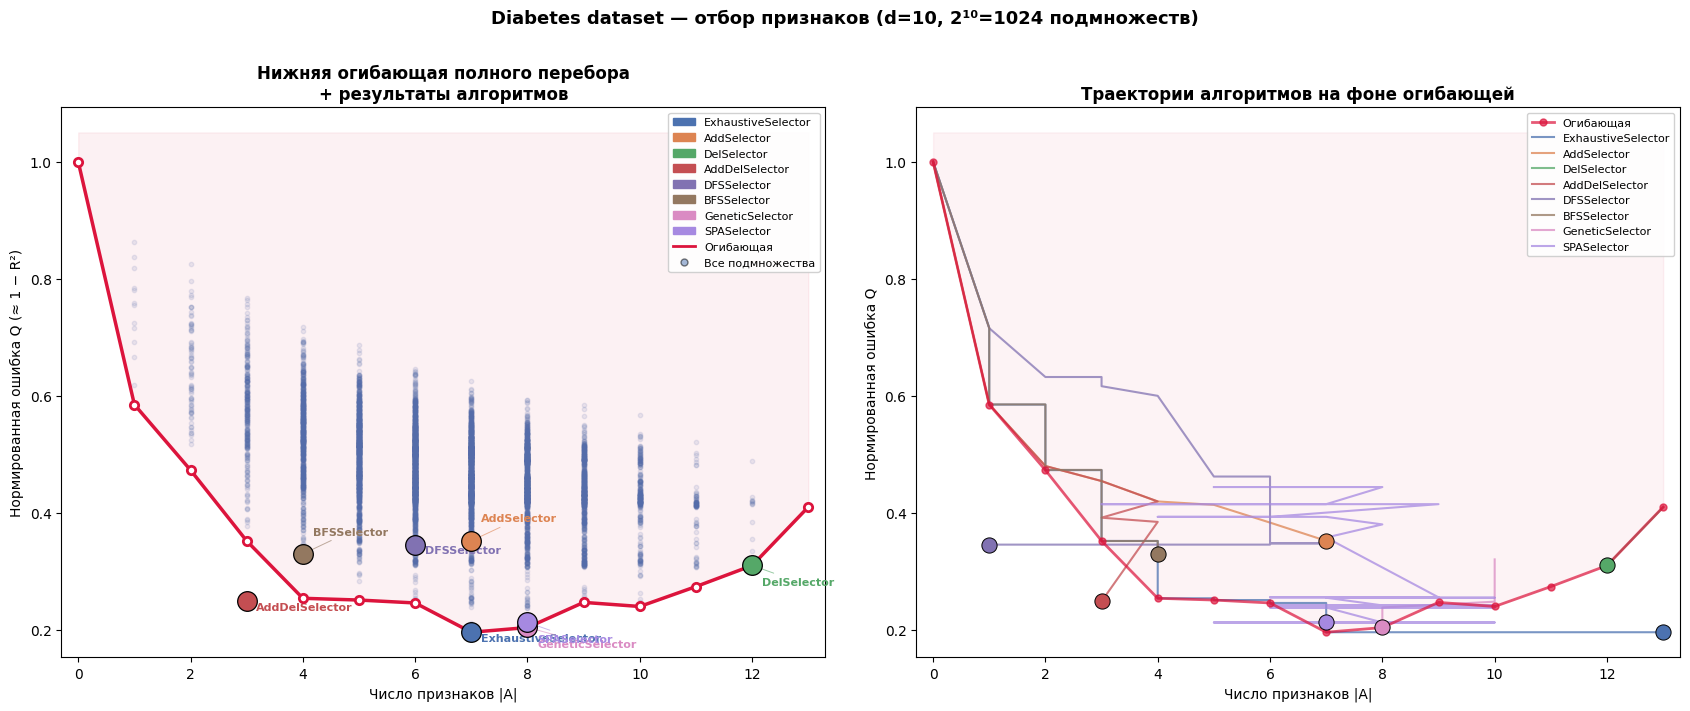

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ── 6a: Огибающая + облако + конечные точки ──────────────────────────────
ax = axes[0]

# Облако всех подмножеств
all_sizes = [r["size"] for r in exh.all_results]
all_scores = [r["score"] for r in exh.all_results]
ax.scatter(all_sizes, all_scores,
           alpha=0.12, s=10, color="#4C72B0", zorder=1, label="Все подмножества")

# Нижняя огибающая
ks = sorted(envelope.keys())
env = [envelope[k] for k in ks]
ax.plot(ks, env, "o-", color="crimson", linewidth=2.5, markersize=6,
        zorder=5, label="Нижняя огибающая", markerfacecolor="white",
        markeredgewidth=2)

# Заливка под огибающей
ax.fill_between(ks, env, 1.05, alpha=0.06, color="crimson")

# Конечные точки методов
for r, color in zip(RESULTS, COLORS):
    k = len(r.best_features)
    q = r.best_score
    ax.scatter(k, q, color=color, s=200, zorder=8,
               edgecolors="black", linewidth=0.9)
    ax.annotate(
        r.method_name, (k, q),
        textcoords="offset points",
        xytext=(7, np.random.choice([-14, 6, -6, 14])),
        fontsize=8, color=color, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.7, alpha=0.6)
    )

ax.set_title("Нижняя огибающая полного перебора\n+ результаты алгоритмов",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Число признаков |A|")
ax.set_ylabel("Нормированная ошибка Q (≈ 1 − R²)")
ax.set_xlim(-0.3, d + 0.3)
leg_patches = (
        [mpatches.Patch(color=c, label=r.method_name)
         for r, c in zip(RESULTS, COLORS)]
        + [plt.Line2D([0], [0], color="crimson", lw=2, label="Огибающая"),
           plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="#4C72B0",
                      markersize=5, alpha=0.5, label="Все подмножества")]
)
ax.legend(handles=leg_patches, fontsize=8, loc="upper right", framealpha=0.9)

# ── 6b: Пути каждого алгоритма на фоне огибающей ─────────────────────────
ax = axes[1]

# Огибающая фоном
ax.plot(ks, env, "o-", color="crimson", linewidth=2, markersize=5,
        zorder=5, label="Огибающая", alpha=0.7)
ax.fill_between(ks, env, 1.05, alpha=0.05, color="crimson")

# Пути (траектории) алгоритмов
for r, color in zip(RESULTS, COLORS):
    if not r.history:
        continue
    # Берём только точки, где известен размер подмножества
    path_k = []
    path_q = []
    best_q = np.inf
    for h in r.history:
        k = len(h["features"])
        q = h["score"]
        if q < best_q:
            best_q = q
        path_k.append(k)
        path_q.append(best_q)

    ax.plot(path_k, path_q, "-", color=color, linewidth=1.5,
            alpha=0.75, label=r.method_name)
    # Финальная точка
    ax.scatter(path_k[-1], path_q[-1], color=color, s=120, zorder=6,
               edgecolors="black", linewidth=0.7)

ax.set_title("Траектории алгоритмов на фоне огибающей",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Число признаков |A|")
ax.set_ylabel("Нормированная ошибка Q")
ax.set_xlim(-0.3, d + 0.3)
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

plt.suptitle("Diabetes dataset — отбор признаков (d=10, 2¹⁰=1024 подмножеств)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

C:\Users\venom\AppData\Local\Temp\ipykernel_6760\968777486.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
C:\Users\venom\AppData\Local\Temp\ipykernel_6760\968777486.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


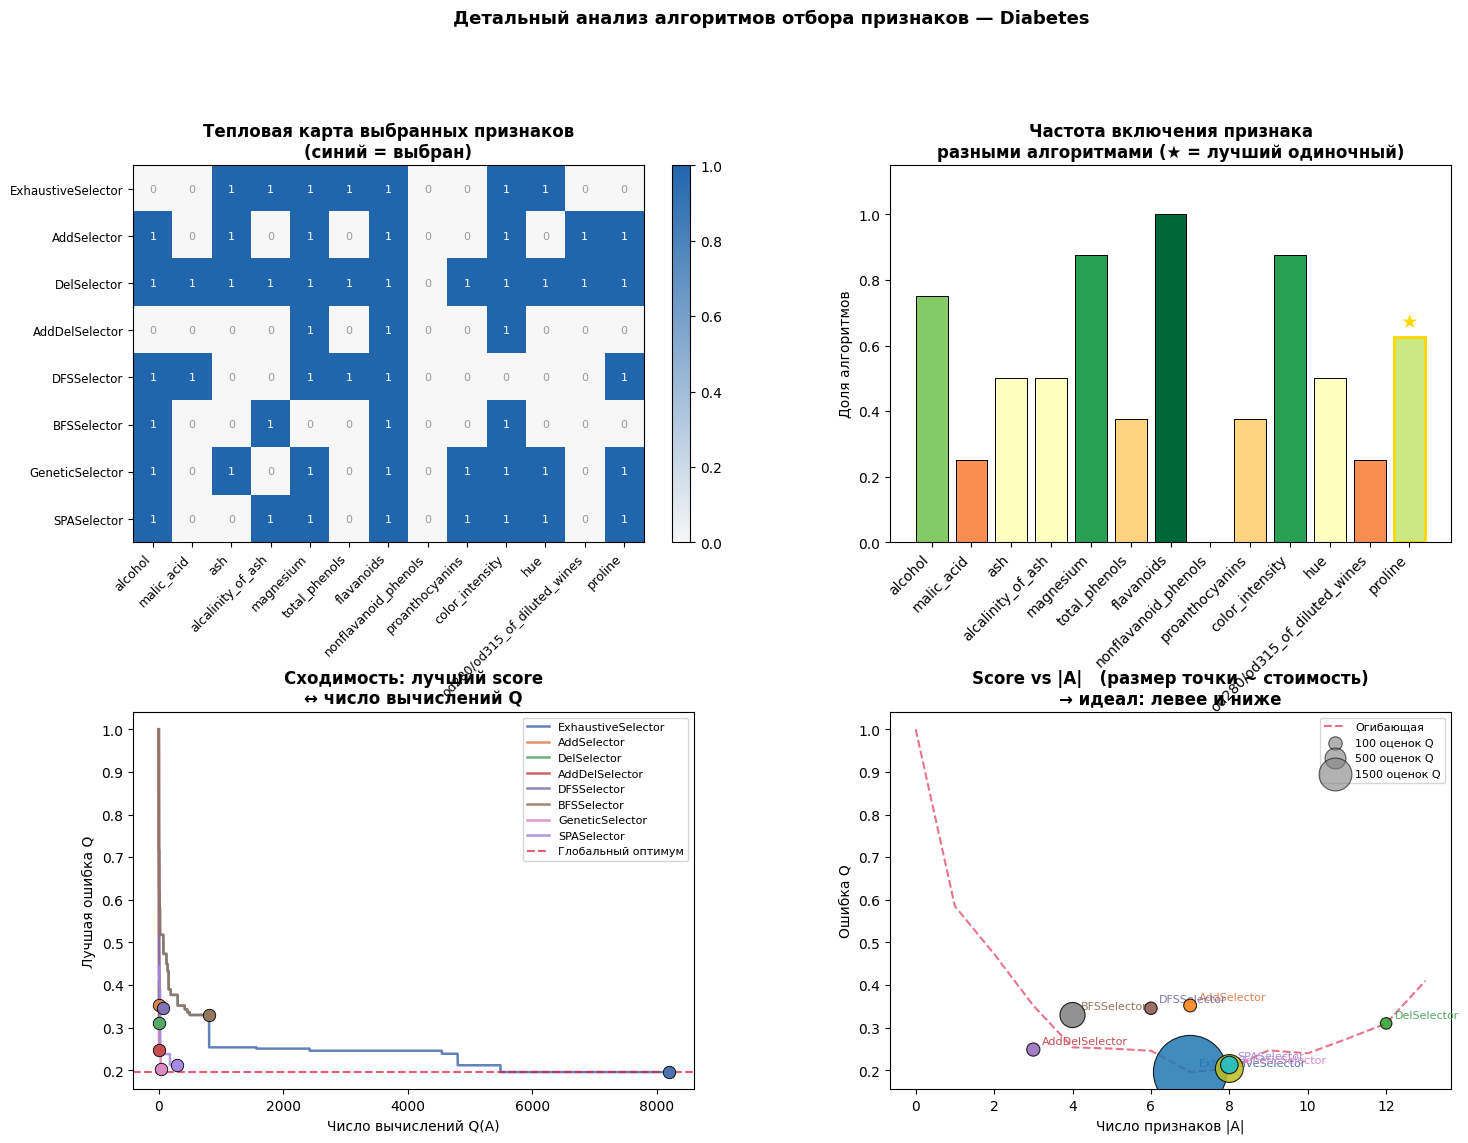

In [135]:
fig = plt.figure(figsize=(17, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 7a: Тепловая карта выбранных признаков ───────────────────────────────
ax = fig.add_subplot(gs[0, 0])

matrix = np.zeros((len(RESULTS), d))
for i, r in enumerate(RESULTS):
    for f in r.best_features:
        matrix[i, f] = 1

cmap_feat = LinearSegmentedColormap.from_list("feat", ["#f7f7f7", "#2166ac"])
im = ax.imshow(matrix, aspect="auto", cmap=cmap_feat, vmin=0, vmax=1,
               interpolation="nearest")

ax.set_yticks(range(len(RESULTS)))
ax.set_yticklabels(METHOD_NAMES, fontsize=8.5)
ax.set_xticks(range(d))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_title("Тепловая карта выбранных признаков\n(синий = выбран)", fontweight="bold")

# Подписи 0/1 в ячейках
for i in range(len(RESULTS)):
    for j in range(d):
        ax.text(j, i, int(matrix[i, j]), ha="center", va="center",
                fontsize=8, color="white" if matrix[i, j] else "#999")

plt.colorbar(im, ax=ax, fraction=0.04)

# ── 7b: Частота выбора признаков разными методами ────────────────────────
ax = fig.add_subplot(gs[0, 1])

freq = matrix.sum(axis=0) / len(RESULTS)
bars = ax.bar(FEATURE_NAMES, freq,
              color=[plt.cm.RdYlGn(f) for f in freq],
              edgecolor="black", linewidth=0.7)

# Важность из огибающей: признак, попавший в лучшее подмножество размера 1
best_k1 = exh.lover_envelope_features().get(1, [])
for j, fname in enumerate(FEATURE_NAMES):
    if j in best_k1:
        ax.text(j, freq[j] + 0.02, "★", ha="center", va="bottom",
                fontsize=14, color="gold")
        bars[j].set_edgecolor("gold")
        bars[j].set_linewidth(2)

ax.set_title("Частота включения признака\nразными алгоритмами (★ = лучший одиночный)",
             fontweight="bold")
ax.set_ylabel("Доля алгоритмов")
ax.set_ylim(0, 1.15)
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")

# ── 7c: Score vs число оценённых подмножеств (эффективность) ─────────────
ax = fig.add_subplot(gs[1, 0])

for r, color in zip(RESULTS, COLORS):
    if not r.history:
        continue
    cum_evals = list(range(1, len(r.history) + 1))
    best_scores = np.minimum.accumulate([h["score"] for h in r.history])
    ax.plot(cum_evals, best_scores, color=color, linewidth=1.8,
            label=r.method_name, alpha=0.88)
    ax.scatter(cum_evals[-1], best_scores[-1], color=color,
               s=80, zorder=5, edgecolors="black", linewidth=0.6)

ax.axhline(envelope[min(envelope, key=envelope.get)], color="crimson",
           linestyle="--", linewidth=1.5, alpha=0.7, label="Глобальный оптимум")
ax.set_title("Сходимость: лучший score\n↔ число вычислений Q", fontweight="bold")
ax.set_xlabel("Число вычислений Q(A)")
ax.set_ylabel("Лучшая ошибка Q")
ax.legend(fontsize=8)

# ── 7d: Итоговое сравнение: score + число признаков ──────────────────────
ax = fig.add_subplot(gs[1, 1])

scores_list = [r.best_score for r in RESULTS]
sizes_list = [len(r.best_features) for r in RESULTS]
n_evals = [r.n_evaluated for r in RESULTS]

sc = ax.scatter(sizes_list, scores_list,
                c=list(range(len(RESULTS))), cmap="tab10",
                s=[60 + e / 3 for e in n_evals],  # размер точки ~ стоимость
                alpha=0.85, edgecolors="black", linewidth=0.8, zorder=5)

# Нижняя огибающая фоном
ax.plot(ks, env, "--", color="crimson", linewidth=1.5, alpha=0.6,
        label="Огибающая", zorder=1)

for i, (r, s, q) in enumerate(zip(RESULTS, sizes_list, scores_list)):
    ax.annotate(r.method_name, (s, q),
                textcoords="offset points", xytext=(6, 4), fontsize=8,
                color=COLORS[i])

# Легенда по размеру точки
legend_sizes = [100, 500, 1500]
for sz in legend_sizes:
    ax.scatter([], [], s=60 + sz / 3, c="gray", alpha=0.6, edgecolors="black",
               linewidth=0.8, label=f"{sz} оценок Q")

ax.set_title("Score vs |A|   (размер точки ~ стоимость)\n→ идеал: левее и ниже",
             fontweight="bold")
ax.set_xlabel("Число признаков |A|")
ax.set_ylabel("Ошибка Q")
ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Детальный анализ алгоритмов отбора признаков — Diabetes",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

C:\Users\venom\AppData\Local\Temp\ipykernel_6760\1211118290.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")


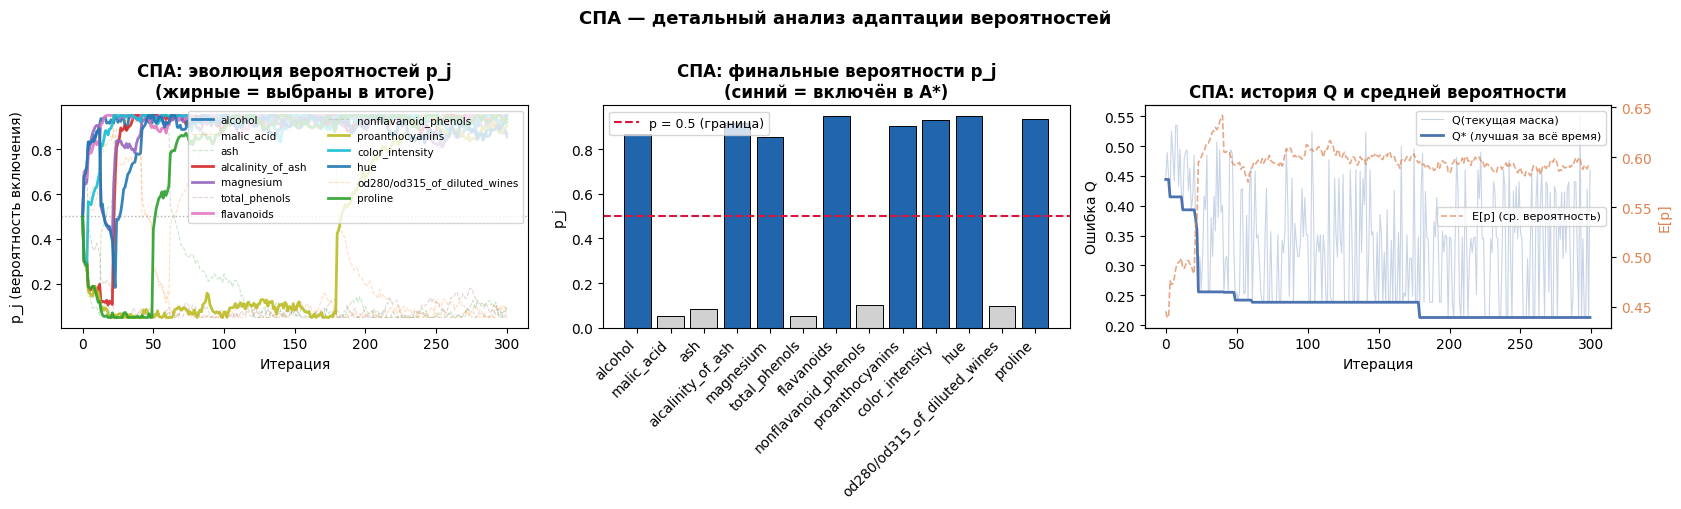

In [136]:
p_hist = r_spa.extra.get("p_history")  # shape: (n_iter+1, d)

if p_hist is not None:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── 8a: Эволюция вероятностей p_j по итерациям ───────────────────
    ax = axes[0]
    for j in range(d):
        alpha_val = 0.9 if j in r_spa.best_features else 0.25
        lw = 2.0 if j in r_spa.best_features else 0.8
        ls = "-" if j in r_spa.best_features else "--"
        ax.plot(p_hist[:, j], linewidth=lw, linestyle=ls, alpha=alpha_val,
                label=FEATURE_NAMES[j])

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_title("СПА: эволюция вероятностей p_j\n(жирные = выбраны в итоге)",
                 fontweight="bold")
    ax.set_xlabel("Итерация")
    ax.set_ylabel("p_j (вероятность включения)")
    ax.legend(fontsize=7.5, loc="upper right", ncol=2)

    # ── 8b: Финальные вероятности ─────────────────────────────────────
    ax = axes[1]
    p_final = p_hist[-1]
    bar_colors = ["#2166ac" if j in r_spa.best_features else "#d1d1d1"
                  for j in range(d)]
    ax.bar(FEATURE_NAMES, p_final, color=bar_colors,
           edgecolor="black", linewidth=0.7)
    ax.axhline(0.5, color="crimson", linestyle="--", linewidth=1.5,
               label="p = 0.5 (граница)")
    ax.set_title("СПА: финальные вероятности p_j\n(синий = включён в A*)",
                 fontweight="bold")
    ax.set_ylabel("p_j")
    ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
    ax.legend(fontsize=9)

    # ── 8c: История score по итерациям СПА ────────────────────────────
    ax = axes[2]
    iter_scores = [h["score"] for h in r_spa.history]
    best_scores = [h["best_score"] for h in r_spa.history]
    p_means = [h["p_mean"] for h in r_spa.history]

    ax.plot(iter_scores, alpha=0.3, color="#4C72B0", linewidth=0.8,
            label="Q(текущая маска)")
    ax.plot(best_scores, color="#4C72B0", linewidth=2,
            label="Q* (лучшая за всё время)")

    ax2_twin = ax.twinx()
    ax2_twin.plot(p_means, color="#DD8452", linewidth=1.2, linestyle="--",
                  alpha=0.7, label="E[p] (ср. вероятность)")
    ax2_twin.set_ylabel("E[p]", color="#DD8452")
    ax2_twin.tick_params(axis="y", labelcolor="#DD8452")

    ax.set_title("СПА: история Q и средней вероятности",
                 fontweight="bold")
    ax.set_xlabel("Итерация")
    ax.set_ylabel("Ошибка Q")
    ax.legend(fontsize=8, loc="upper right")
    ax2_twin.legend(fontsize=8, loc="center right")

    plt.suptitle("СПА — детальный анализ адаптации вероятностей",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

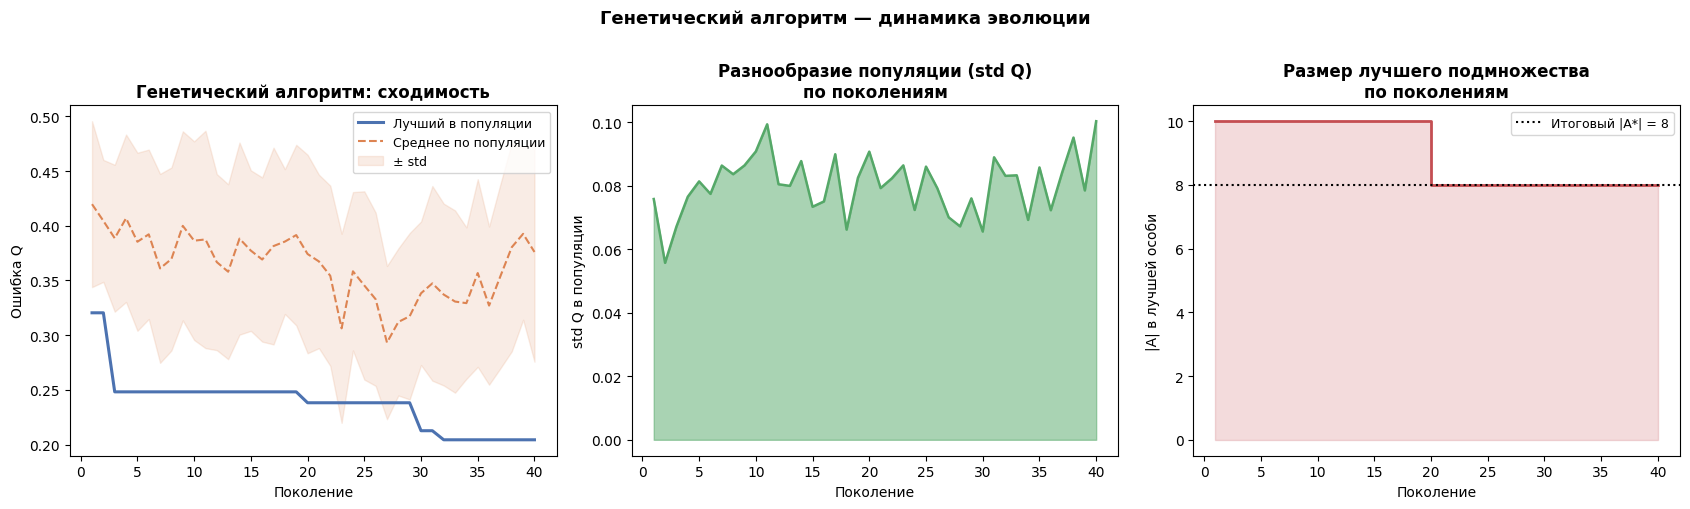

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

gen_hist = [h for h in r_gen.history if "gen_mean" in h]
gens = [h["generation"] for h in gen_hist]
gen_best = [h["score"] for h in gen_hist]
gen_mean = [h["gen_mean"] for h in gen_hist]
gen_std = [h["gen_std"] for h in gen_hist]

# ── 9a: Сходимость best / mean / std ──────────────────────────────────
ax = axes[0]
ax.plot(gens, gen_best, color="#4C72B0", linewidth=2.2, label="Лучший в популяции")
ax.plot(gens, gen_mean, color="#DD8452", linewidth=1.5, linestyle="--",
        label="Среднее по популяции")
ax.fill_between(
    gens,
    np.array(gen_mean) - np.array(gen_std),
    np.array(gen_mean) + np.array(gen_std),
    alpha=0.15, color="#DD8452", label="± std"
)
ax.set_title("Генетический алгоритм: сходимость",
             fontweight="bold")
ax.set_xlabel("Поколение")
ax.set_ylabel("Ошибка Q")
ax.legend(fontsize=9)

# ── 9b: Разнообразие популяции (std) по поколениям ────────────────────
ax = axes[1]
ax.fill_between(gens, gen_std, alpha=0.5, color="#55A868")
ax.plot(gens, gen_std, color="#55A868", linewidth=1.8)
ax.set_title("Разнообразие популяции (std Q)\nпо поколениям", fontweight="bold")
ax.set_xlabel("Поколение")
ax.set_ylabel("std Q в популяции")

# ── 9c: Число признаков в лучшей особи по поколениям ──────────────────
ax = axes[2]
n_feat_per_gen = [len(h["features"]) for h in gen_hist]
ax.step(gens, n_feat_per_gen, color="#C44E52", linewidth=2, where="post")
ax.fill_between(gens, n_feat_per_gen, alpha=0.2, color="#C44E52", step="post")
ax.axhline(len(r_gen.best_features), color="black", linestyle=":",
           linewidth=1.5, label=f"Итоговый |A*| = {len(r_gen.best_features)}")
ax.set_title("Размер лучшего подмножества\nпо поколениям", fontweight="bold")
ax.set_xlabel("Поколение")
ax.set_ylabel("|A| в лучшей особи")
ax.legend(fontsize=9)

plt.suptitle("Генетический алгоритм — динамика эволюции",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()